In [1]:
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded!")

All libraries loaded!


In [2]:
# Simulating real-world credit card transaction data
np.random.seed(42)
n_legit = 9000
n_fraud = 500  # fraud is always rare in real world!

# Legitimate transactions
legit = pd.DataFrame({
    'amount': np.random.normal(150, 80, n_legit).clip(1, 2000),
    'hour': np.random.randint(6, 23, n_legit),       # normal hours
    'age': np.random.randint(25, 65, n_legit),
    'transaction_count_today': np.random.randint(1, 6, n_legit),
    'distance_from_home_km': np.random.normal(10, 8, n_legit).clip(0, 100),
    'is_foreign_transaction': np.random.choice([0, 1], n_legit, p=[0.95, 0.05]),
    'class': 0  # 0 = legitimate
})

# Fraudulent transactions
fraud = pd.DataFrame({
    'amount': np.random.normal(900, 300, n_fraud).clip(100, 5000),  # high amounts
    'hour': np.random.choice([0,1,2,3,4,23], n_fraud),              # odd hours
    'age': np.random.randint(18, 80, n_fraud),
    'transaction_count_today': np.random.randint(5, 20, n_fraud),   # many txns
    'distance_from_home_km': np.random.normal(200, 100, n_fraud).clip(50, 1000),
    'is_foreign_transaction': np.random.choice([0, 1], n_fraud, p=[0.3, 0.7]),
    'class': 1  # 1 = fraud
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=42)
print(f"Dataset created!")
print(f"Total transactions : {len(df)}")
print(f"Legitimate         : {len(legit)} ({len(legit)/len(df)*100:.1f}%)")
print(f"Fraudulent         : {len(fraud)} ({len(fraud)/len(df)*100:.1f}%)")
df.head()

Dataset created!
Total transactions : 9500
Legitimate         : 9000 (94.7%)
Fraudulent         : 500 (5.3%)


,amount,hour,age,transaction_count_today,distance_from_home_km,is_foreign_transaction,class
952,49.876846,17,40,2,8.935848,0,0
6599,289.275319,6,62,4,0.000000,0,0
4220,1.000000,13,55,5,13.903222,0,0
2554,80.536581,21,59,4,16.416239,0,0
4519,78.173595,21,59,1,19.344648,0,0


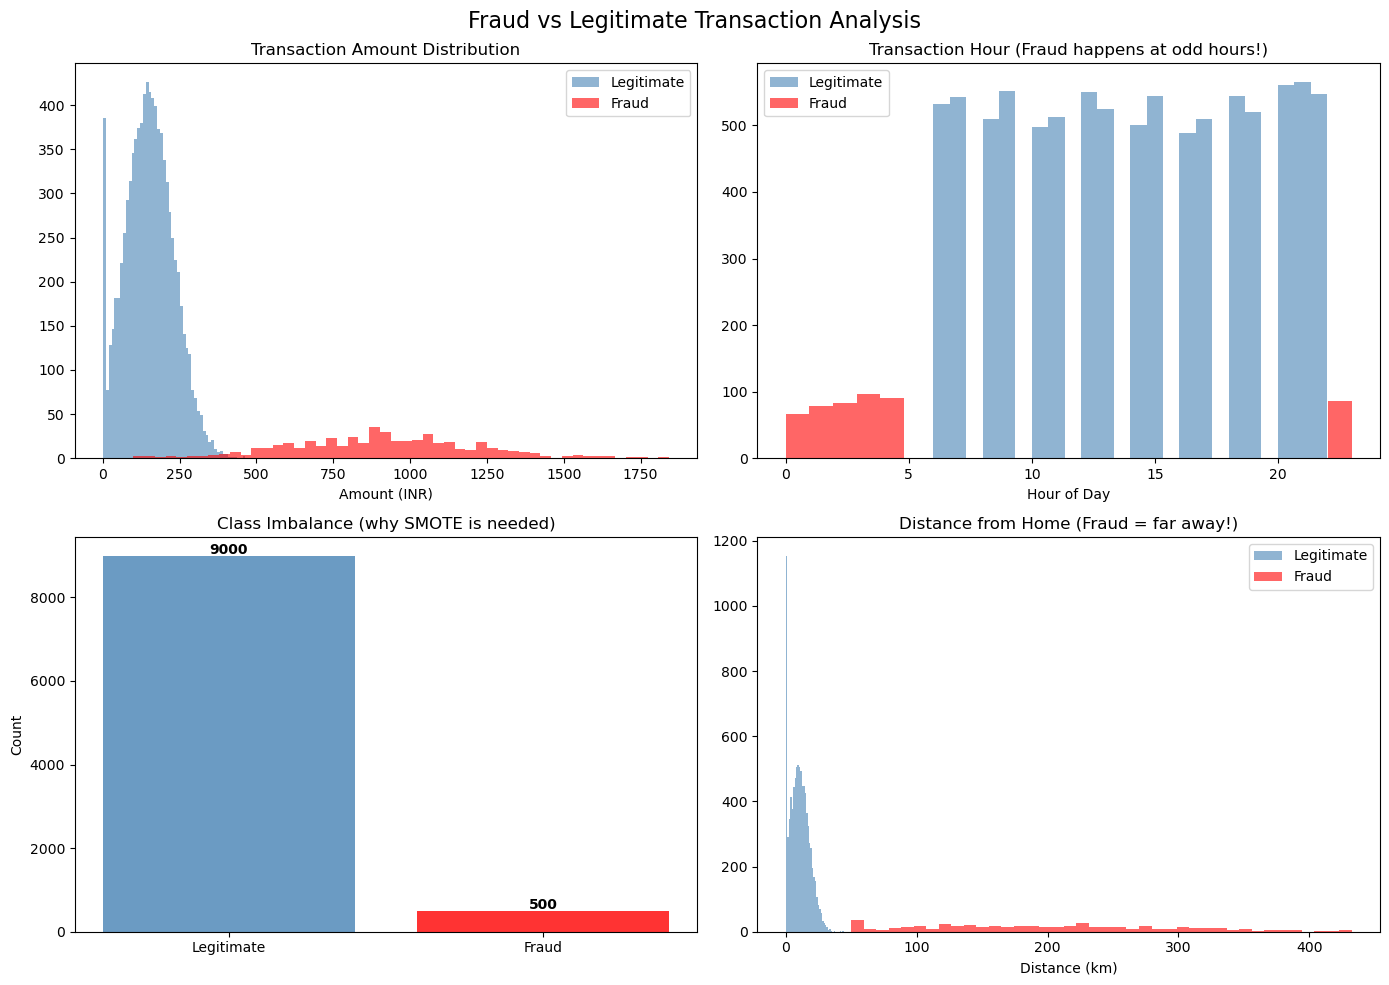

EDA complete!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud vs Legitimate Transaction Analysis', fontsize=16)

# 1. Transaction Amount Distribution
axes[0,0].hist(df[df['class']==0]['amount'], bins=50, alpha=0.6,
               color='steelblue', label='Legitimate')
axes[0,0].hist(df[df['class']==1]['amount'], bins=50, alpha=0.6,
               color='red', label='Fraud')
axes[0,0].set_title('Transaction Amount Distribution')
axes[0,0].set_xlabel('Amount (INR)')
axes[0,0].legend()

# 2. Transaction Hour Distribution
axes[0,1].hist(df[df['class']==0]['hour'], bins=24, alpha=0.6,
               color='steelblue', label='Legitimate')
axes[0,1].hist(df[df['class']==1]['hour'], bins=24, alpha=0.6,
               color='red', label='Fraud')
axes[0,1].set_title('Transaction Hour (Fraud happens at odd hours!)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].legend()

# 3. Class Balance
class_counts = df['class'].value_counts()
axes[1,0].bar(['Legitimate', 'Fraud'], class_counts.values,
               color=['steelblue', 'red'], alpha=0.8)
axes[1,0].set_title('Class Imbalance (why SMOTE is needed)')
axes[1,0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1,0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 4. Distance from Home
axes[1,1].hist(df[df['class']==0]['distance_from_home_km'], bins=40,
               alpha=0.6, color='steelblue', label='Legitimate')
axes[1,1].hist(df[df['class']==1]['distance_from_home_km'], bins=40,
               alpha=0.6, color='red', label='Fraud')
axes[1,1].set_title('Distance from Home (Fraud = far away!)')
axes[1,1].set_xlabel('Distance (km)')
axes[1,1].legend()

plt.tight_layout()
plt.show()
print("EDA complete!")

In [4]:
# Separate features and target
X = df.drop('class', axis=1)
y = df['class']

# Scale the features (very important for ML!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\n Before SMOTE:")
print(f"Fraud in training    : {sum(y_train==1)}")
print(f"Legitimate in training: {sum(y_train==0)}")

# SMOTE — Synthetic Minority Oversampling
# Creates fake fraud samples so model learns fraud better!
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Fraud in training    : {sum(y_train_sm==1)}")
print(f"Legitimate in training: {sum(y_train_sm==0)}")

Training samples : 7600
Testing samples  : 1900

 Before SMOTE:
Fraud in training    : 400
Legitimate in training: 7200

After SMOTE:
Fraud in training    : 7200
Legitimate in training: 7200


In [5]:
# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2: Random Forest (our main model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=" * 50)
print(" MODEL COMPARISON")
print("=" * 50)
print(f"Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"Random Forest Accuracy       : {rf_acc*100:.2f}%")
print(f"\n Best Model: Random Forest")

 MODEL COMPARISON
Logistic Regression Accuracy : 100.00%
Random Forest Accuracy       : 100.00%

 Best Model: Random Forest


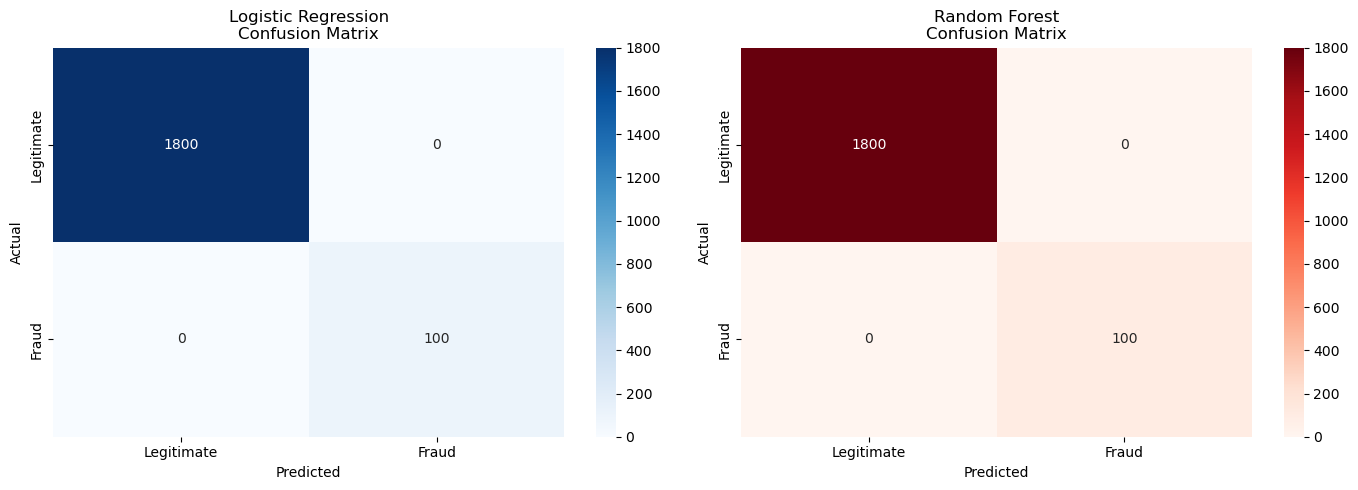


Random Forest Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1800
       Fraud       1.00      1.00      1.00       100

    accuracy                           1.00      1900
   macro avg       1.00      1.00      1.00      1900
weighted avg       1.00      1.00      1.00      1900



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Legitimate', 'Fraud']))

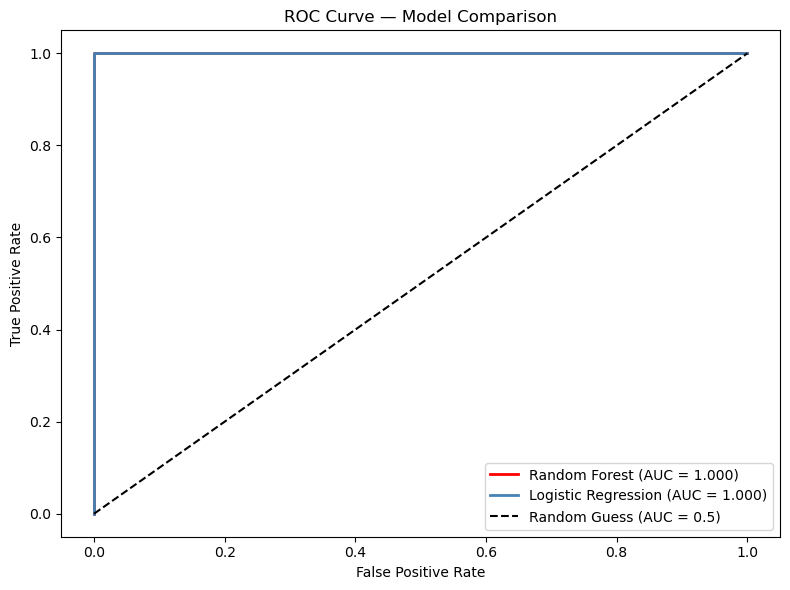

Random Forest AUC Score: 1.000
(Closer to 1.0 = better model!)


In [7]:
# ROC AUC Score — the gold standard for fraud detection!
rf_proba = rf.predict_proba(X_test)[:, 1]
lr_proba = lr.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)

auc_rf = roc_auc_score(y_test, rf_proba)
auc_lr = roc_auc_score(y_test, lr_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='red',
         label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, color='steelblue',
         label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Forest AUC Score: {auc_rf:.3f}")
print("(Closer to 1.0 = better model!)")

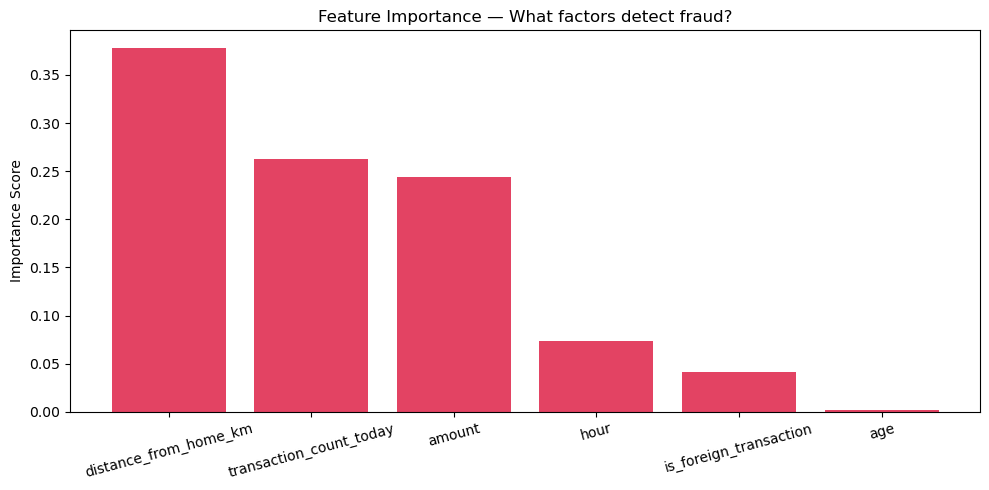

Top fraud indicators:
  distance_from_home_km          → 0.3774
  transaction_count_today        → 0.2623
  amount                         → 0.2436
  hour                           → 0.0738
  is_foreign_transaction         → 0.0415
  age                            → 0.0014


In [9]:
features = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(features)),
        importances[indices], color='crimson', alpha=0.8)
plt.xticks(range(len(features)),
           [features[i] for i in indices], rotation=15)
plt.title('Feature Importance — What factors detect fraud?')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top fraud indicators:")
for i in indices:
    print(f"  {features[i]:<30} → {importances[i]:.4f}")

In [1]:
# EDITABLE — Change these values to test any transaction!
test_transaction = {
    'amount': 4500,        # ← Transaction amount in INR
    'hour': 2,             # ← Hour of day (0-23)
    'age': 35,             # ← Cardholder age
    'transaction_count_today': 12,  # ← How many txns today
    'distance_from_home_km': 850,   # ← Distance from home
    'is_foreign_transaction': 1     # ← 0=domestic, 1=foreign
}

input_df = pd.DataFrame([test_transaction])
input_scaled = scaler.transform(input_df)
prediction = rf.predict(input_scaled)[0]
probability = rf.predict_proba(input_scaled)[0]

print("=" * 50)
print("TRANSACTION DETAILS")
print("=" * 50)
for k, v in test_transaction.items():
    print(f"  {k:<30}: {v}")

print("\n" + "=" * 50)
print("MODEL PREDICTION")
print("=" * 50)
if prediction == 1:
    print(f"  FRAUD DETECTED!")
    print(f"  Fraud Probability    : {probability[1]*100:.1f}%")
    print(f"  → Transaction BLOCKED")
else:
    print(f"  LEGITIMATE Transaction")
    print(f"  Legitimate Probability: {probability[0]*100:.1f}%")
    print(f"  → Transaction APPROVED")

NameError: name 'pd' is not defined